# Phylogenetic tree trimming and validation

**Tree review for the integrated path18 panel (n = 18)**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## Question and decision

How was the time-calibrated tree reduced to the exact integrated panel, and did
the trim preserve the intended topology and branch-time information? The frozen
analysis tree contains exact species matches only. It does not substitute nearby
species, and genomic and microscopy specimens remain independent evidence streams.

In [2]:
artifacts = [
    "input_data/phylogeny/desmo900dated_test.tre",
    "results/data/corrected/phylogeny/desmognathus_time_tree_analysis18_v1.nwk",
    "results/data/corrected/phylogeny/stewart_wiens_2025_main_analysis18_v1.nwk",
    "results/data/corrected/phylogeny/stewart_wiens_2025_bootstrap_analysis18_v1.nex",
    "results/data/corrected/phylogeny/phylogeny_tip_crosswalk_analysis18_v1.csv",
    "results/data/corrected/phylogeny/phylogeny_tree_metrics_analysis18_v1.csv",
    "results/data/corrected/phylogeny/phylogeny_release_audit_analysis18_v1.manifest.json",
]
display(artifact_table(artifacts))
panel = read_csv("path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv")
crosswalk = read_csv("results/data/corrected/phylogeny/phylogeny_tip_crosswalk_analysis18_v1.csv")
metrics = read_csv("results/data/corrected/phylogeny/phylogeny_tree_metrics_analysis18_v1.csv")
assert len(panel) == 18 and panel.species.is_unique
assert len(crosswalk) == 18 and set(crosswalk.species) == set(panel.species)
display(panel[["species", "te_sra_accession", "te_assembly_accession", "decision_basis"]])
display(metrics)

,artifact,frozen_artifact,exists,size_mb
0,input_data/phylogeny/desmo900dated_test.tre,results/data/research_review/frozen_inputs/input_data/phylogeny/desmo900dated_test.tre,True,0.001
1,results/data/corrected/phylogeny/desmognathus_time_tree_analysis18_v1.nwk,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/desmognathus_time_tree_analysis18_v1.nwk,True,0.001
2,results/data/corrected/phylogeny/stewart_wiens_2025_main_analysis18_v1.nwk,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/stewart_wiens_2025_main_analysis18_v1.nwk,True,0.000
3,results/data/corrected/phylogeny/stewart_wiens_2025_bootstrap_analysis18_v1.nex,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/stewart_wiens_2025_bootstrap_analysis18_...,True,0.103
4,results/data/corrected/phylogeny/phylogeny_tip_crosswalk_analysis18_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/phylogeny_tip_crosswalk_analysis18_v1.csv,True,0.004
5,results/data/corrected/phylogeny/phylogeny_tree_metrics_analysis18_v1.csv,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/phylogeny_tree_metrics_analysis18_v1.csv,True,0.001
6,results/data/corrected/phylogeny/phylogeny_release_audit_analysis18_v1.manifest.json,results/data/research_review/frozen_inputs/results/data/corrected/phylogeny/phylogeny_release_audit_analysis18_v1.ma...,True,0.003


,species,te_sra_accession,te_assembly_accession,decision_basis
0,amphileucus,SRX20502537,GCA_032360725.1,active WGS and current linked-cell record
1,anicetus,SRX21425396,GCA_033119125.1,active WGS and current linked-cell record
2,apalachicolae,SRX19952657,GCA_030264955.1,active WGS and current linked-cell record
3,auriculatus,SRX19953419,GCA_030264895.1,active WGS and current linked-cell record
4,bairdi,SRX21425397,GCA_034783875.1,active WGS and current linked-cell record
5,campi,SRX21425398,GCA_033118305.1,active WGS and current linked-cell record
6,fuscus,SRX20497025,GCA_032353935.1,active reidentified SRX20497025 resource and current linked-cell record
7,gvnigeusgwotli,SRX20502827,GCA_032353775.1,active WGS and current linked-cell record
8,intermedius,SRX20502776,GCA_032275315.1,active WGS and current linked-cell record
9,kanawha,SRX20502939,GCA_032353855.1,active WGS and current linked-cell record; terminal-internal proxy absent


,tree_id,path,sha256,n_tips,n_internal_nodes,root_degree,rooted_by_root_degree,fully_bifurcating,all_branch_lengths_present,all_branch_lengths_positive,minimum_branch_length_myr,maximum_branch_length_myr,root_age_myr,minimum_root_to_tip_myr,maximum_root_to_tip_myr,root_to_tip_range_myr,ultrametric_at_1e_5_myr_tolerance,strict_ultrametric_at_1e_10_myr,duplicate_exact_tip_labels,source_sha256,derivation,maximum_terminal_padding_myr
0,local_source_46_tip,input_data/phylogeny/desmo900dated_test.tre,1cf561526405c794b70d5767182eefe84dfa1552f9f9c0be6b36c465b19301aa,46,45,2,True,True,True,True,0.257436,25.529739,30.574569,30.574567,30.574569,0.000002,True,False,False,NaN,NaN,NaN
1,tracked_processed_34_tip,results/phylogeny/processed_phylogeny.nwk,5a81b7edcc0bf1c035c896051a249c5837ebbbabafdb74c29b3fc03e2f3ad771,34,33,2,True,True,True,True,0.234849,20.423791,24.459655,24.459654,24.459655,0.000002,True,False,False,NaN,NaN,NaN
2,corrected_final_panel_18_tip,results/data/corrected/phylogeny/desmognathus_time_tree_analysis18_v1.nwk,5dcd3c874636081fe9852747ac0d4d79f68a44ed93d72eff68c6bdba089b40bb,18,17,2,True,True,True,True,0.344797,11.799855,16.708337,16.708337,16.708337,0.000000,True,True,False,1cf561526405c794b70d5767182eefe84dfa1552f9f9c0be6b36c465b19301aa,exact_tip_prune_then_terminal_padding_to_max_root_to_tip,0.000002


## Source tree versus exact path18 trim

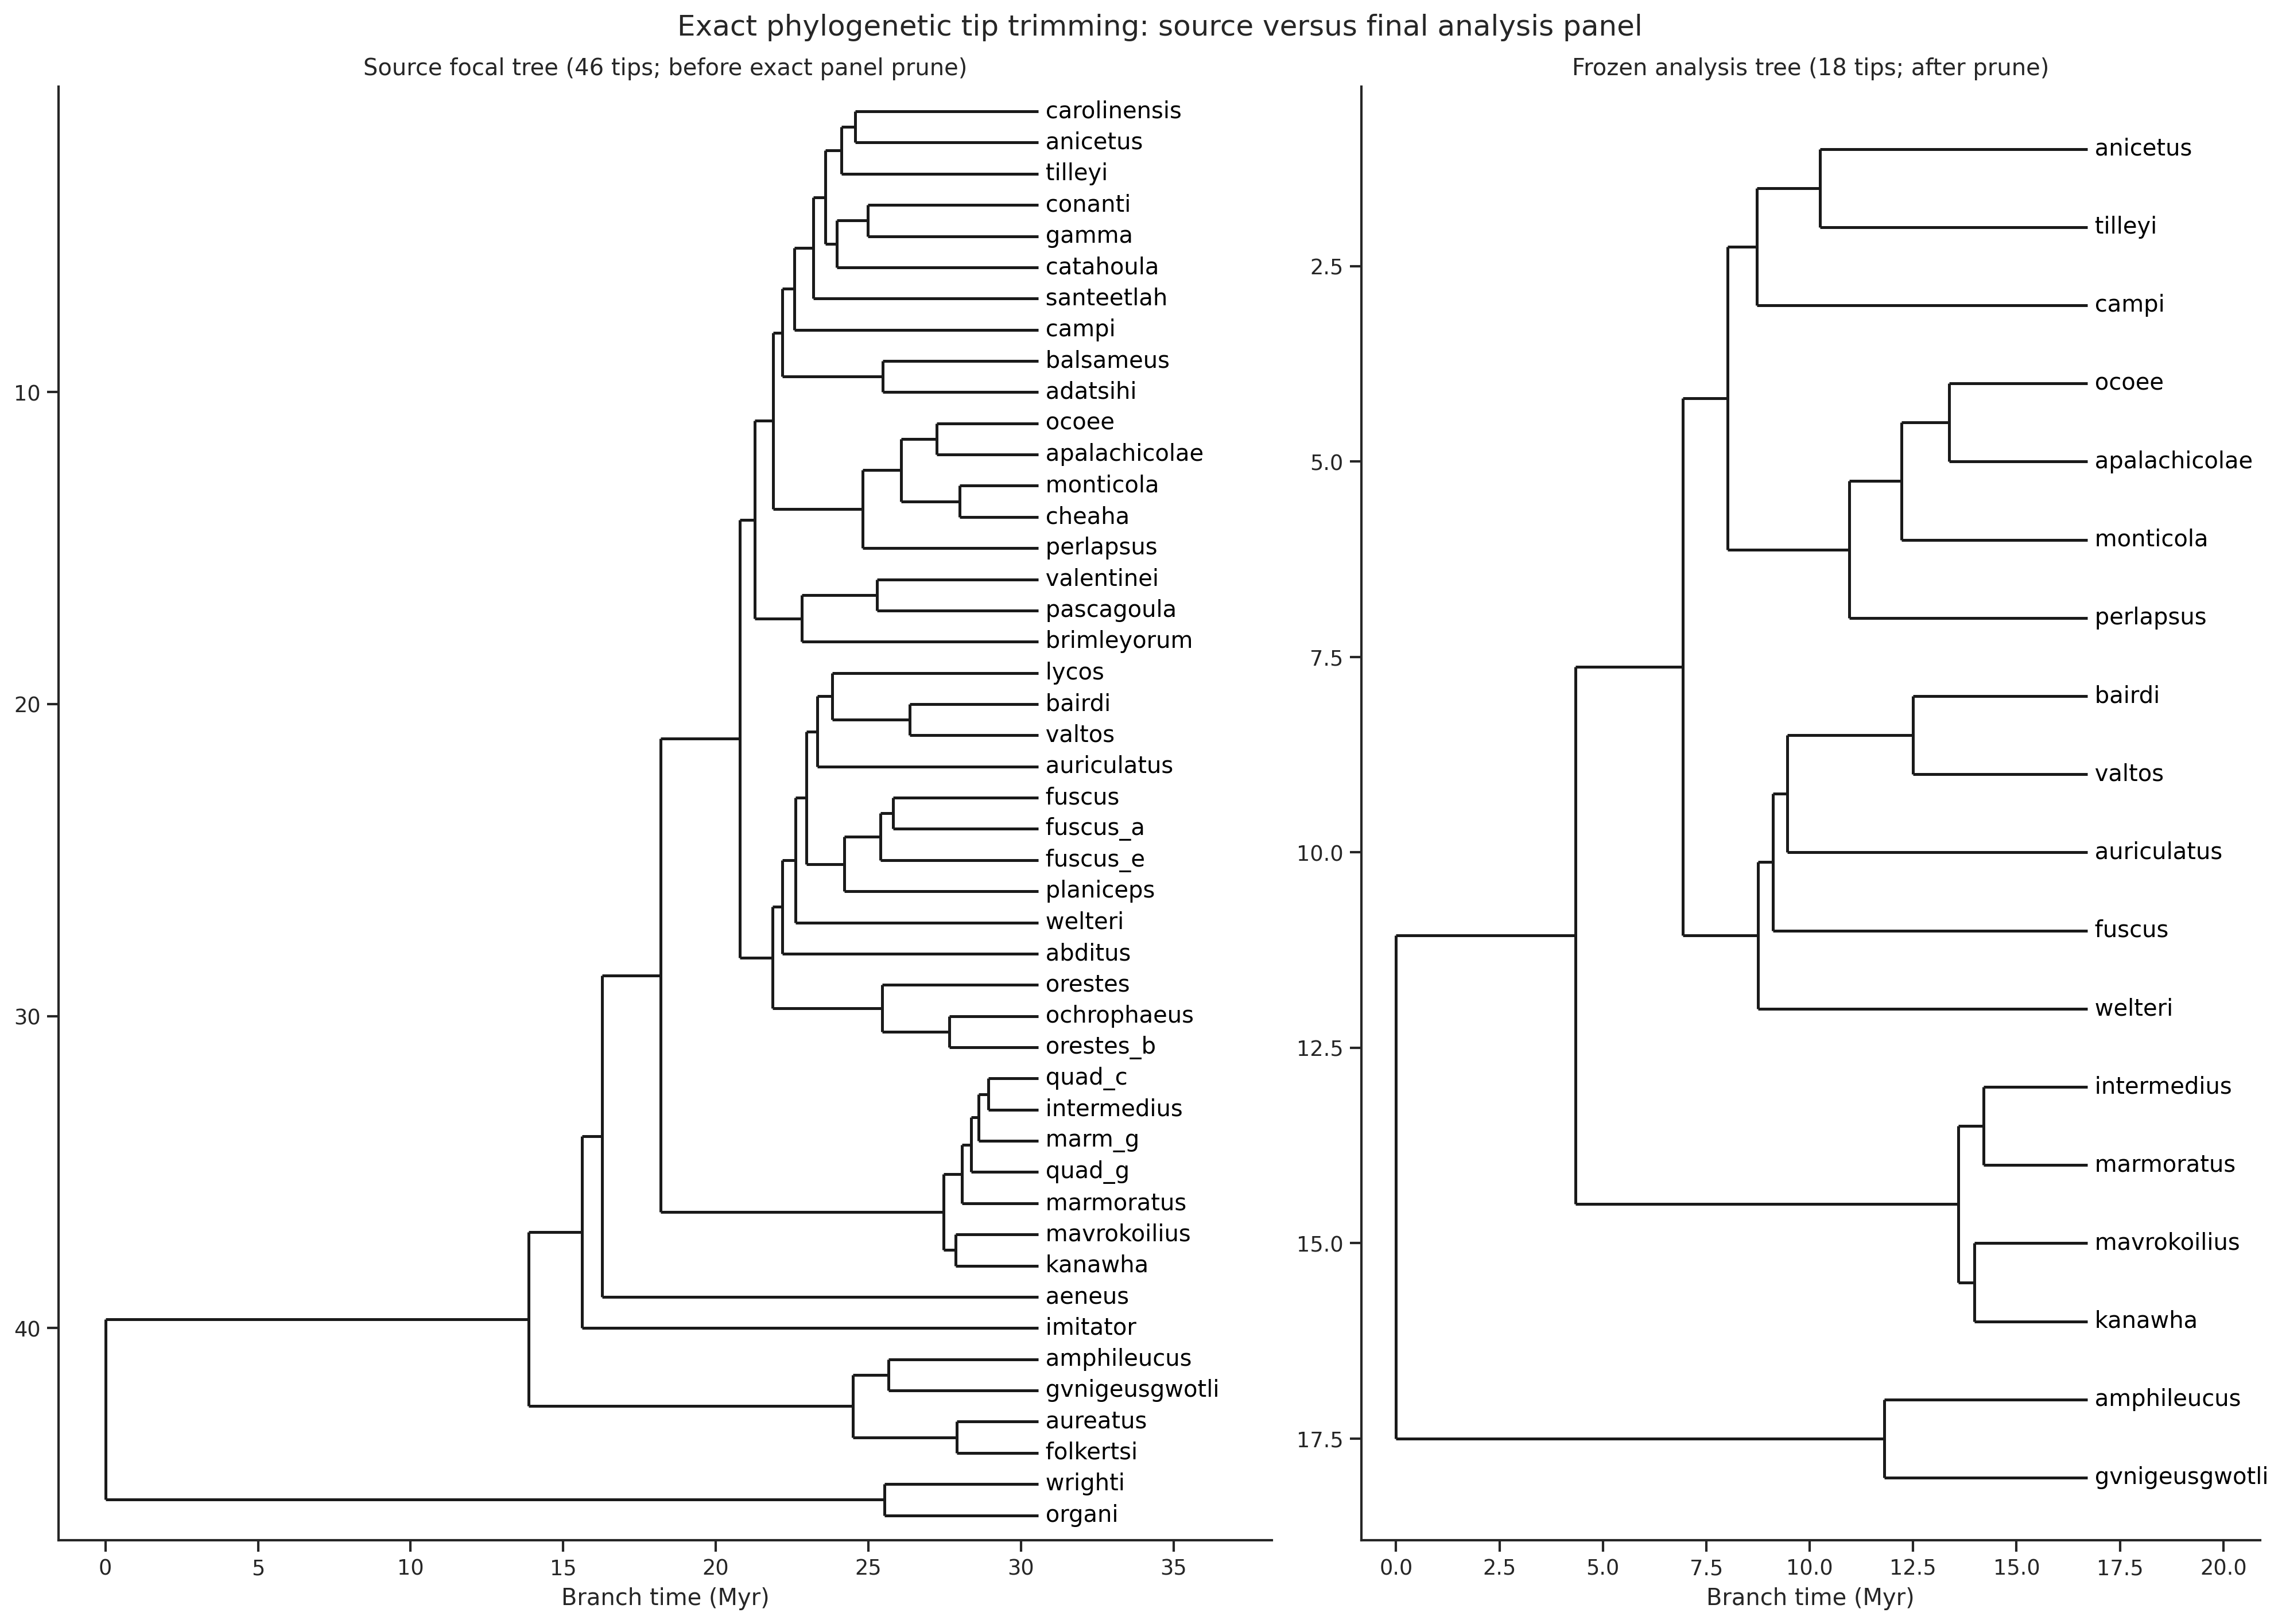

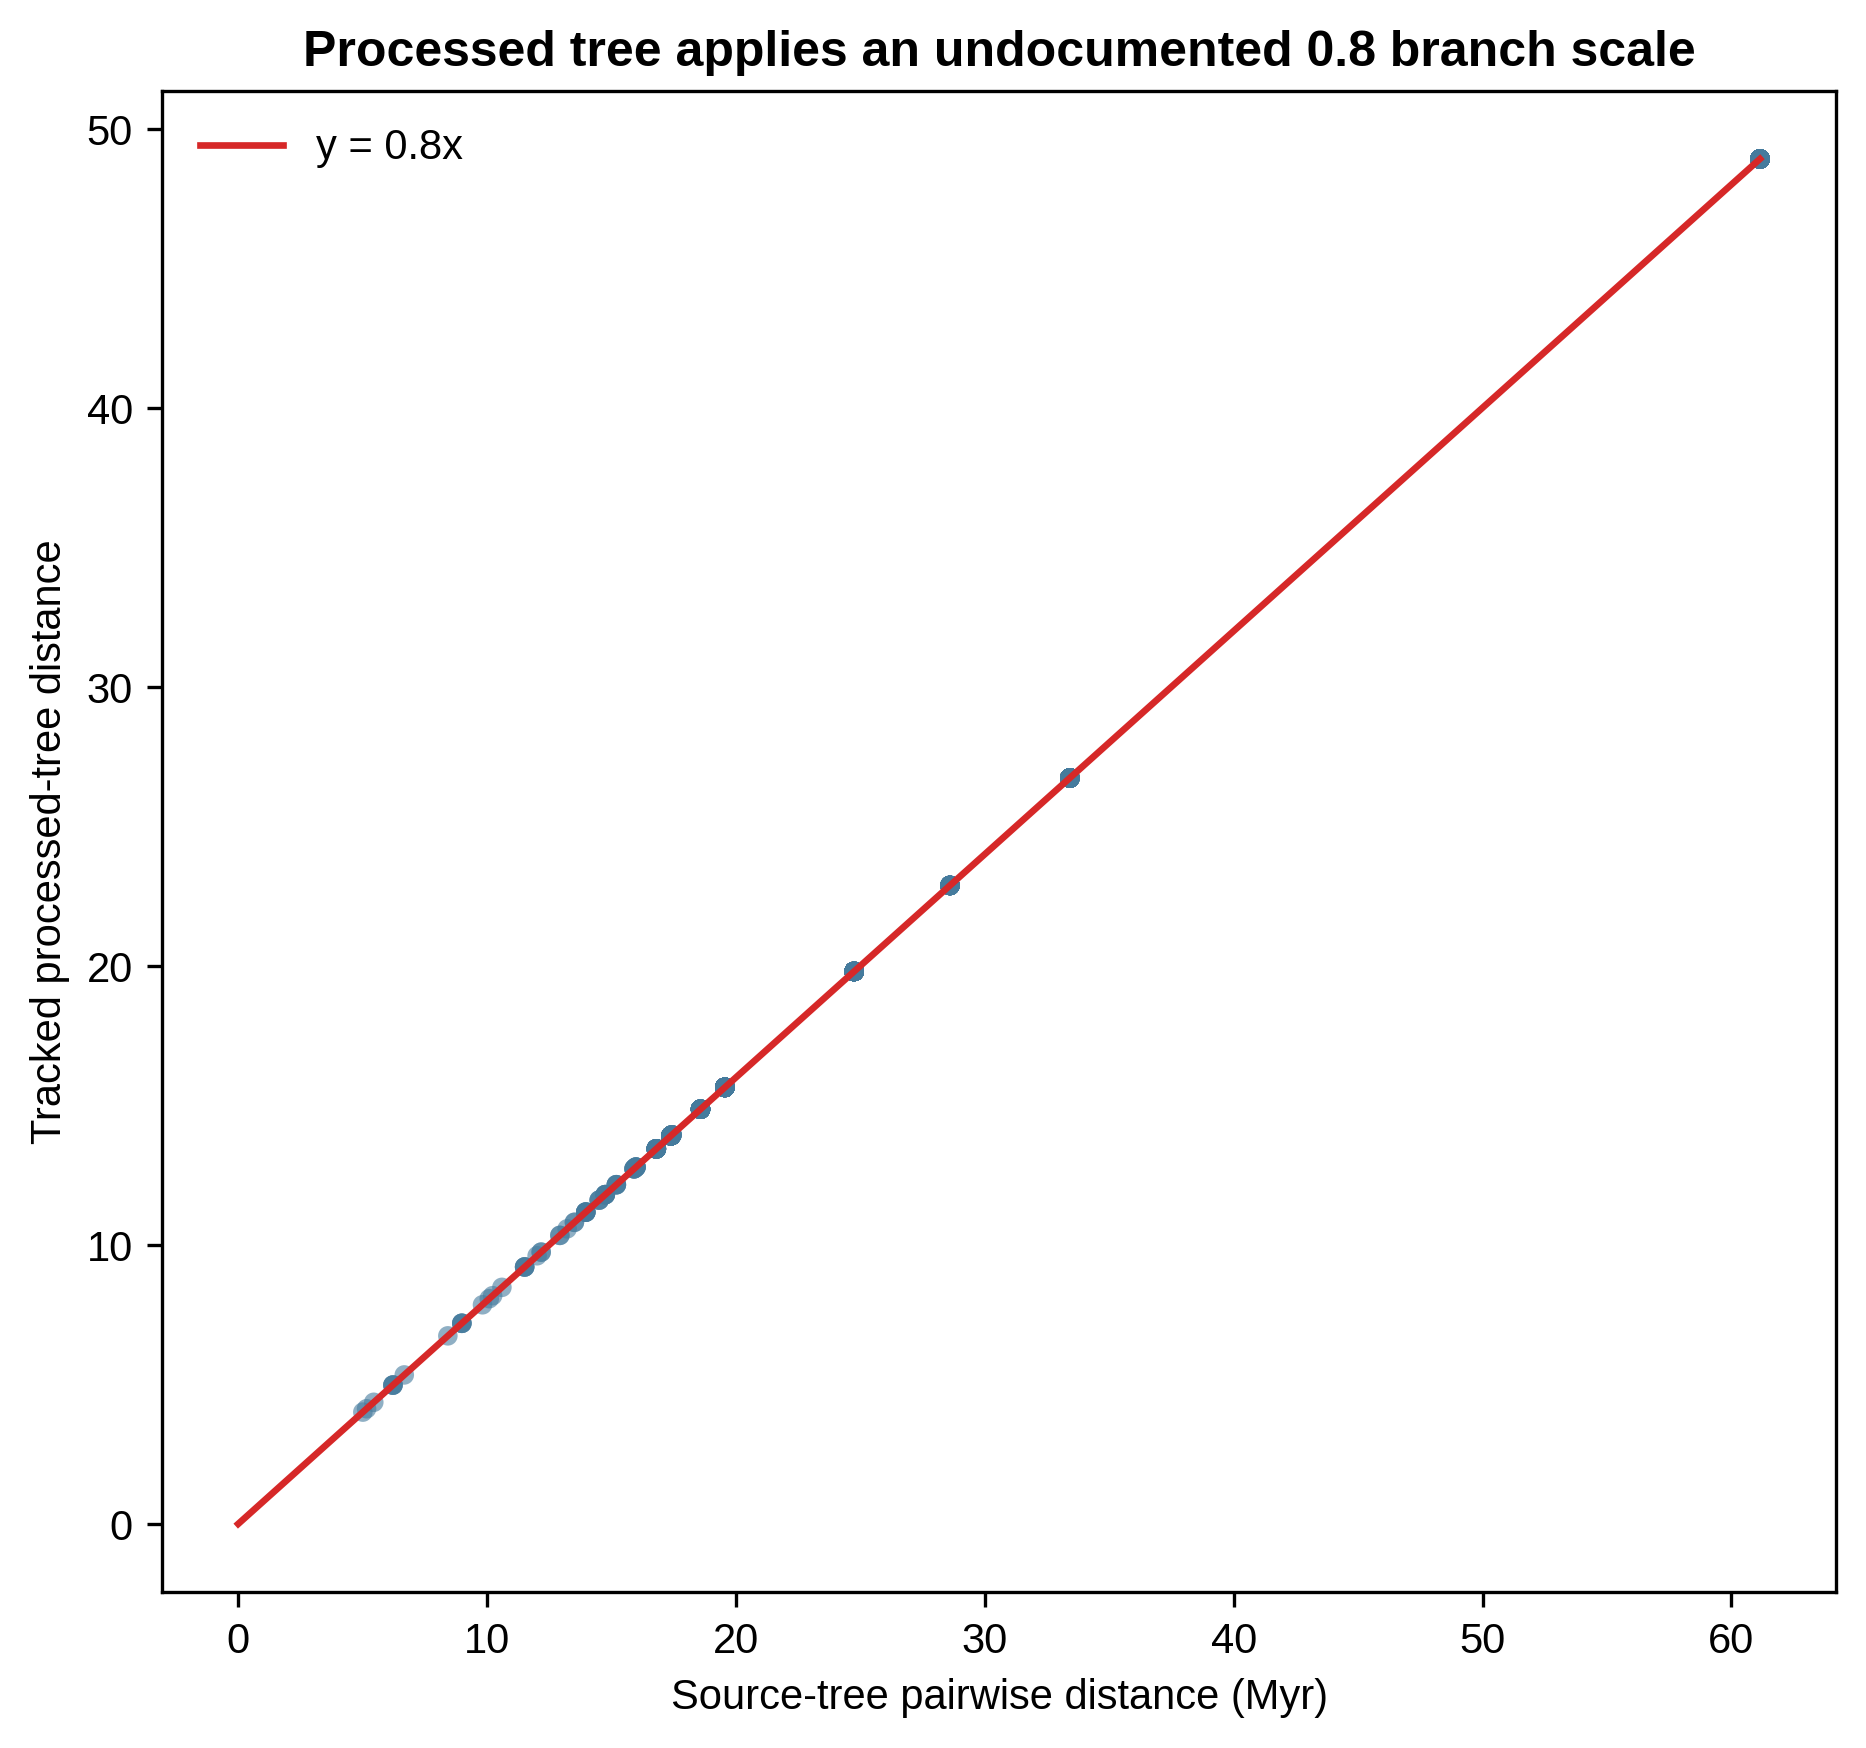

In [3]:
show_figure("results/figures/presentation_notebooks/phylogeny/phylogeny_source46_vs_final18_trim_analysis18_v1.png")
show_figure("results/figures/corrected/phylogeny/phylogeny_processed_scale_comparison_v1.png")

## Topology, calibration, and uncertainty checks

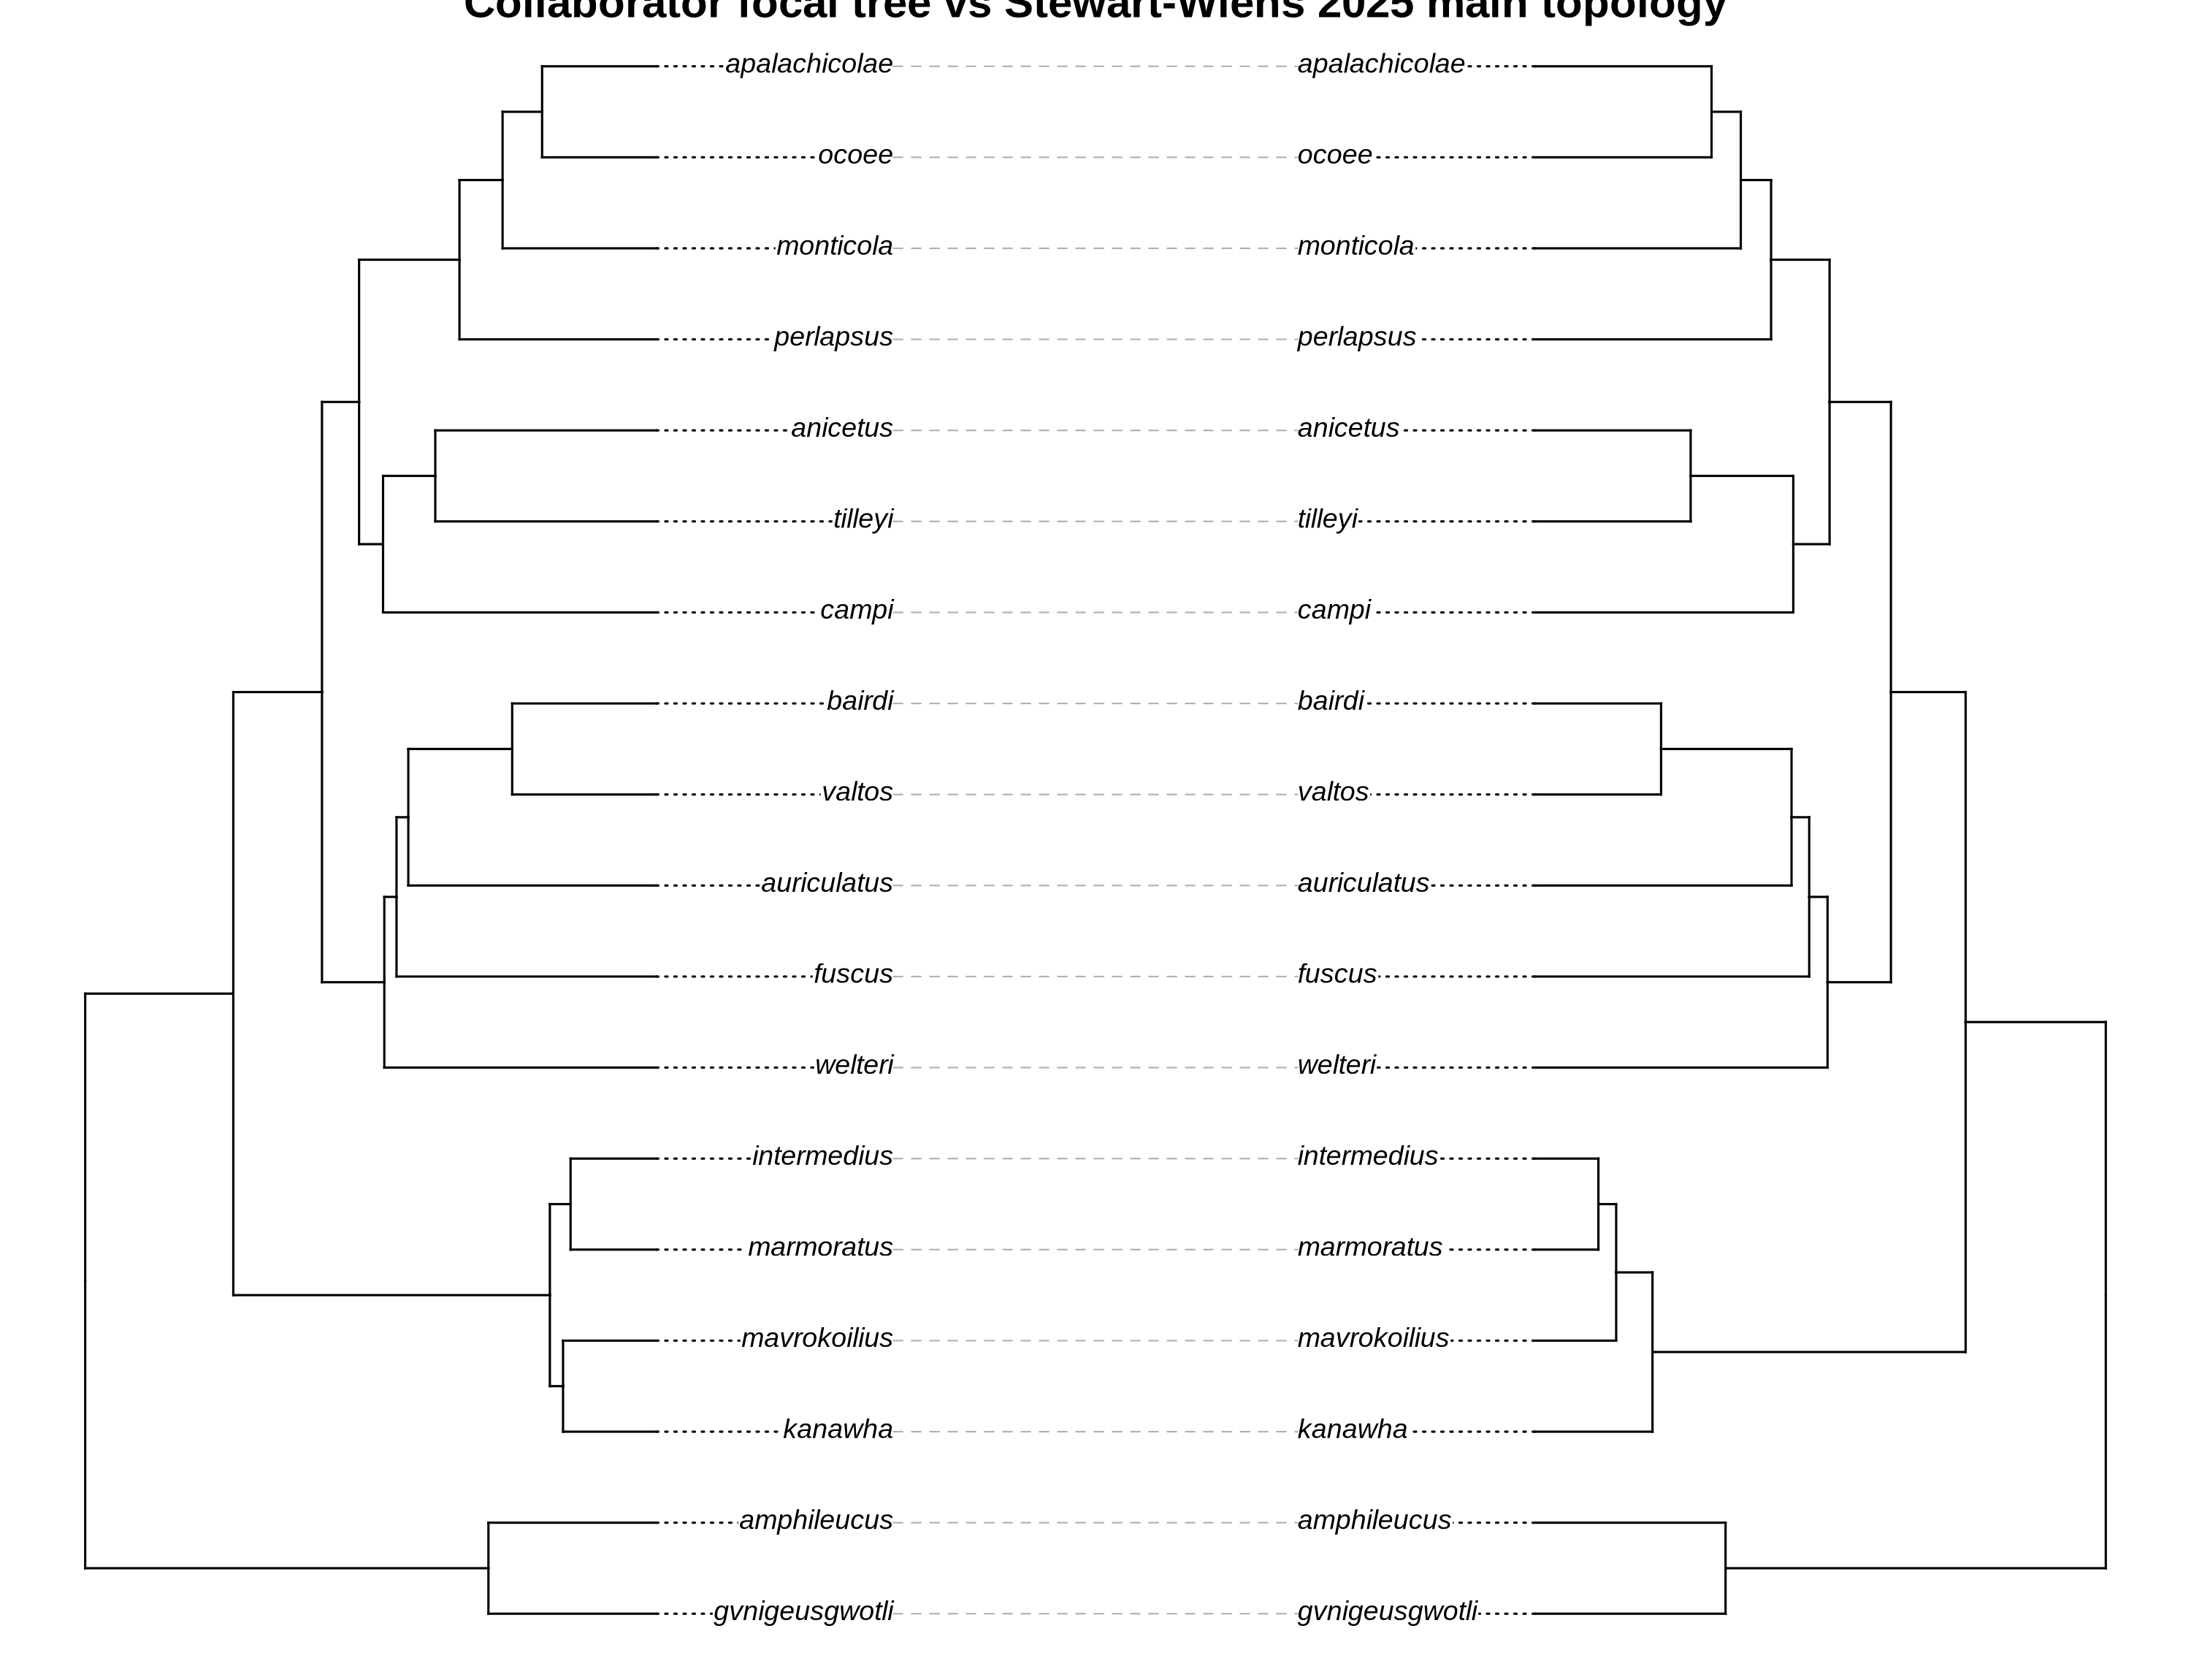

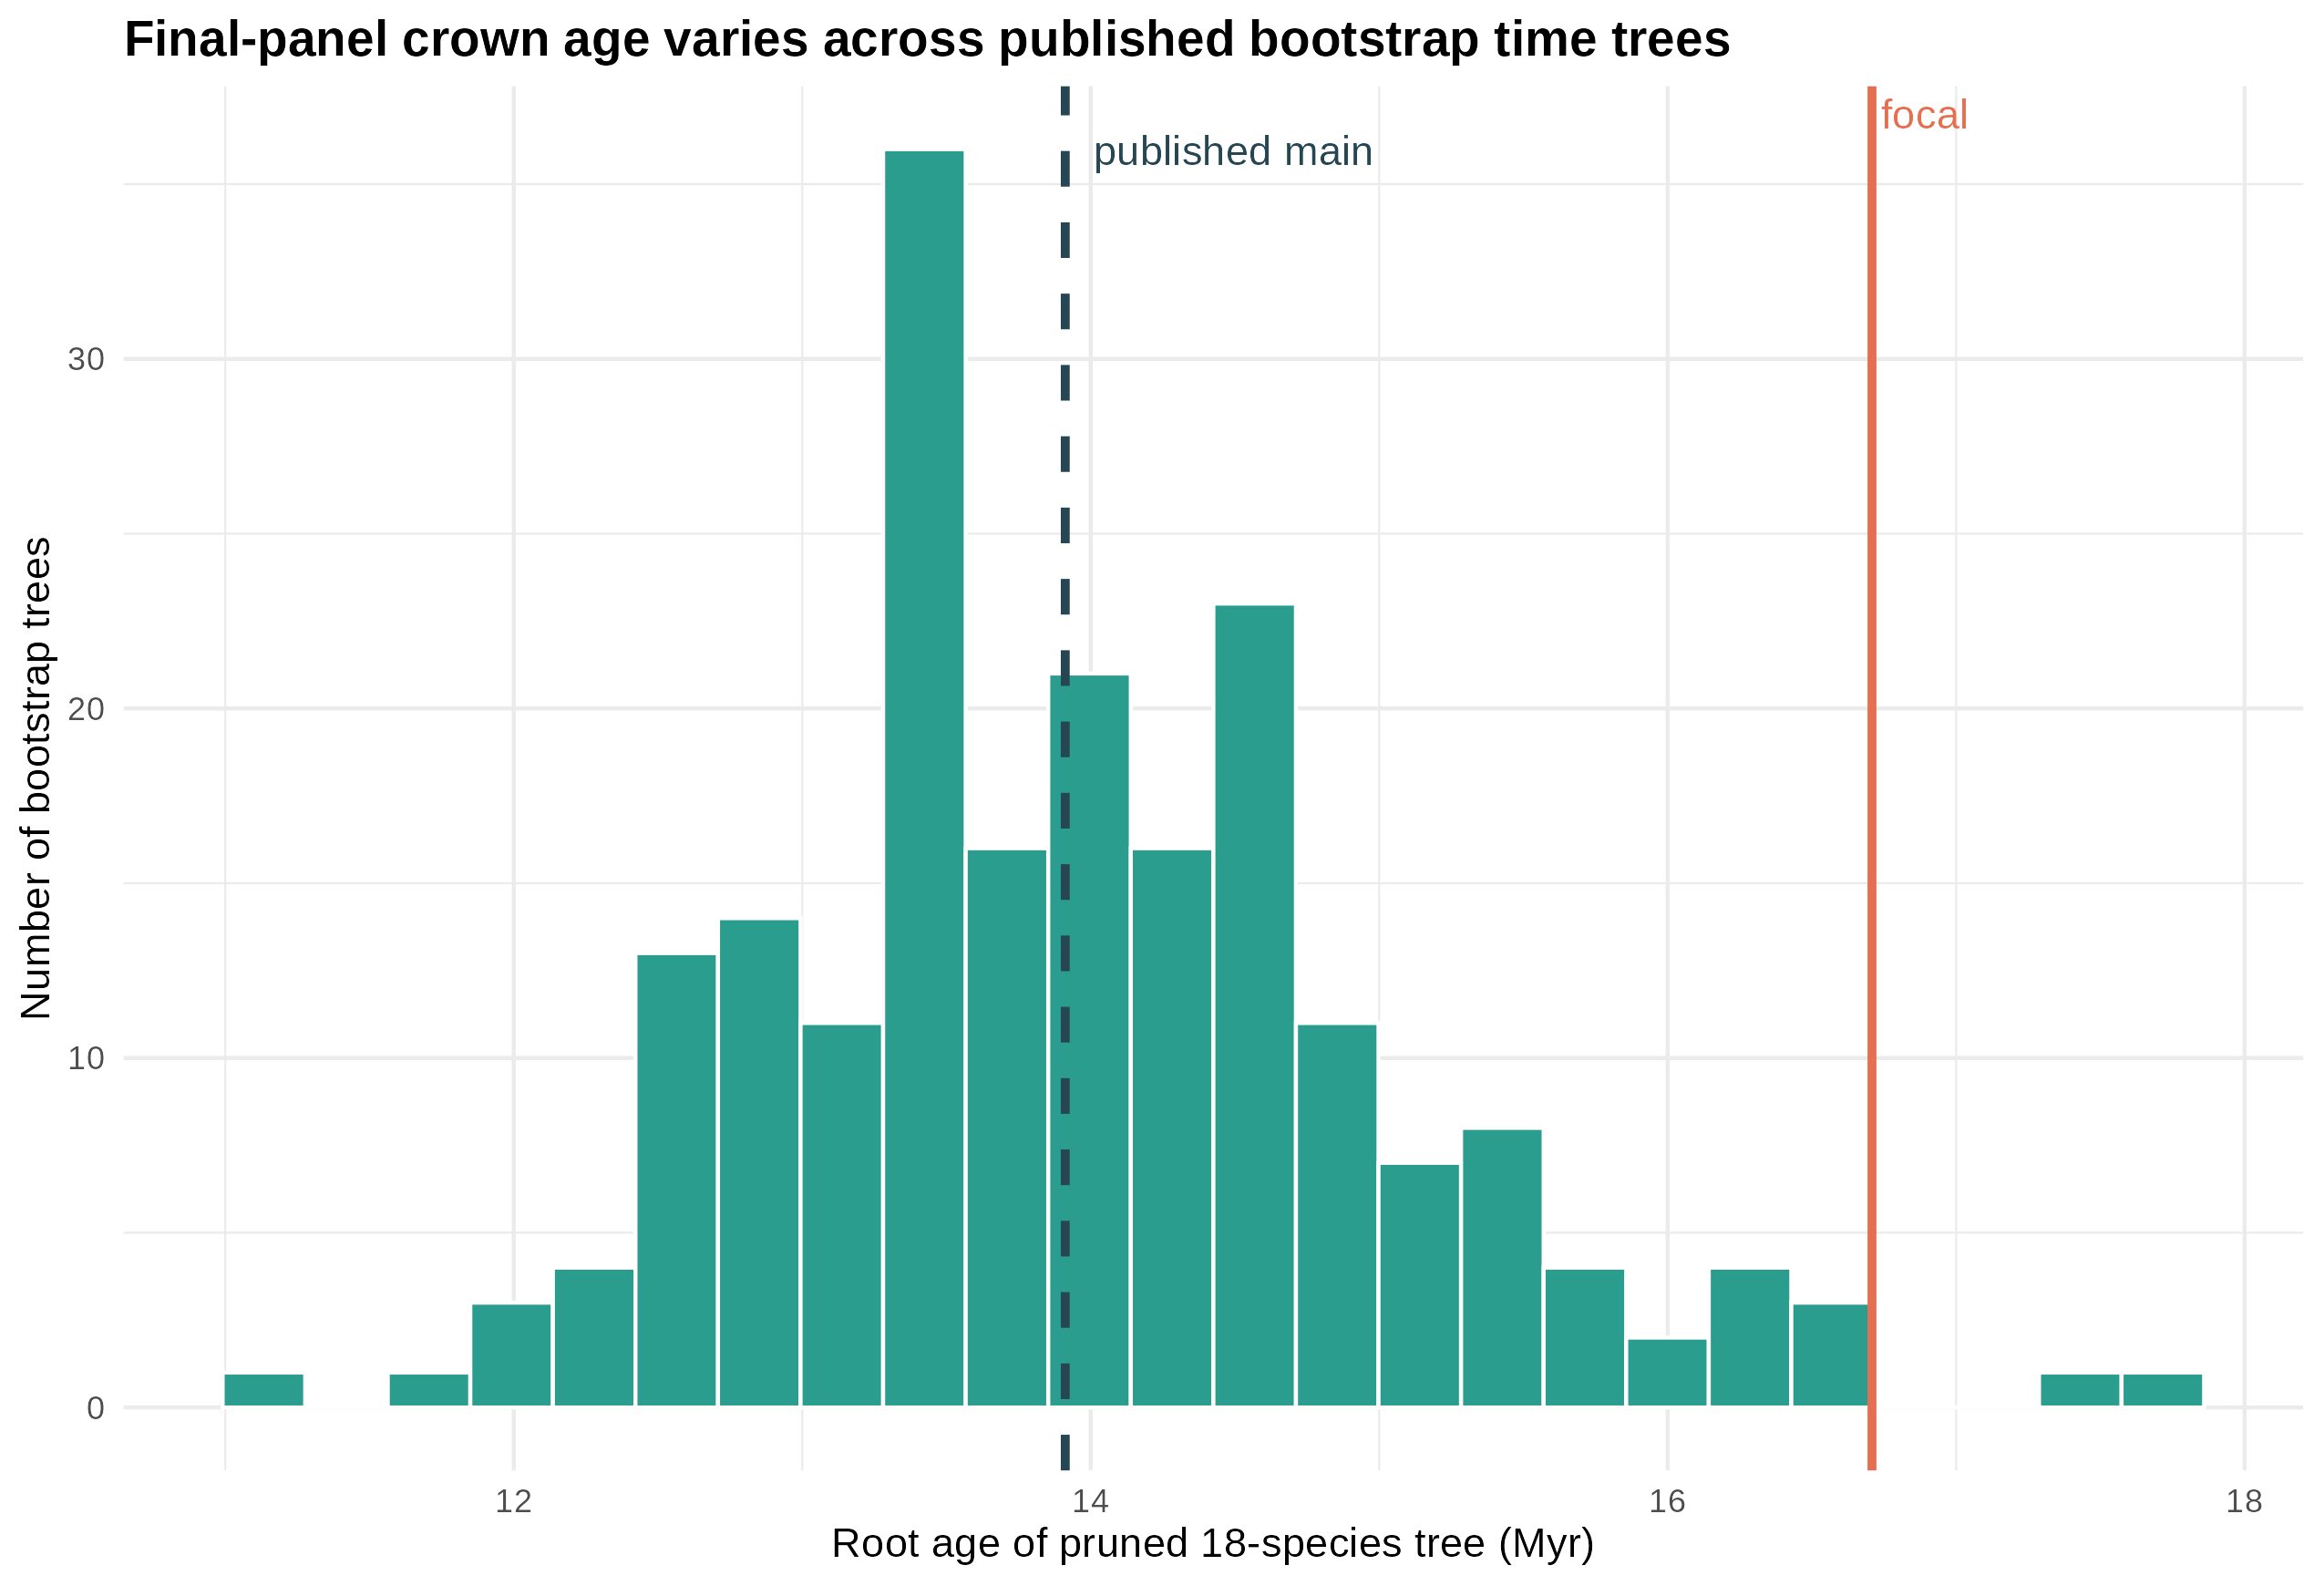

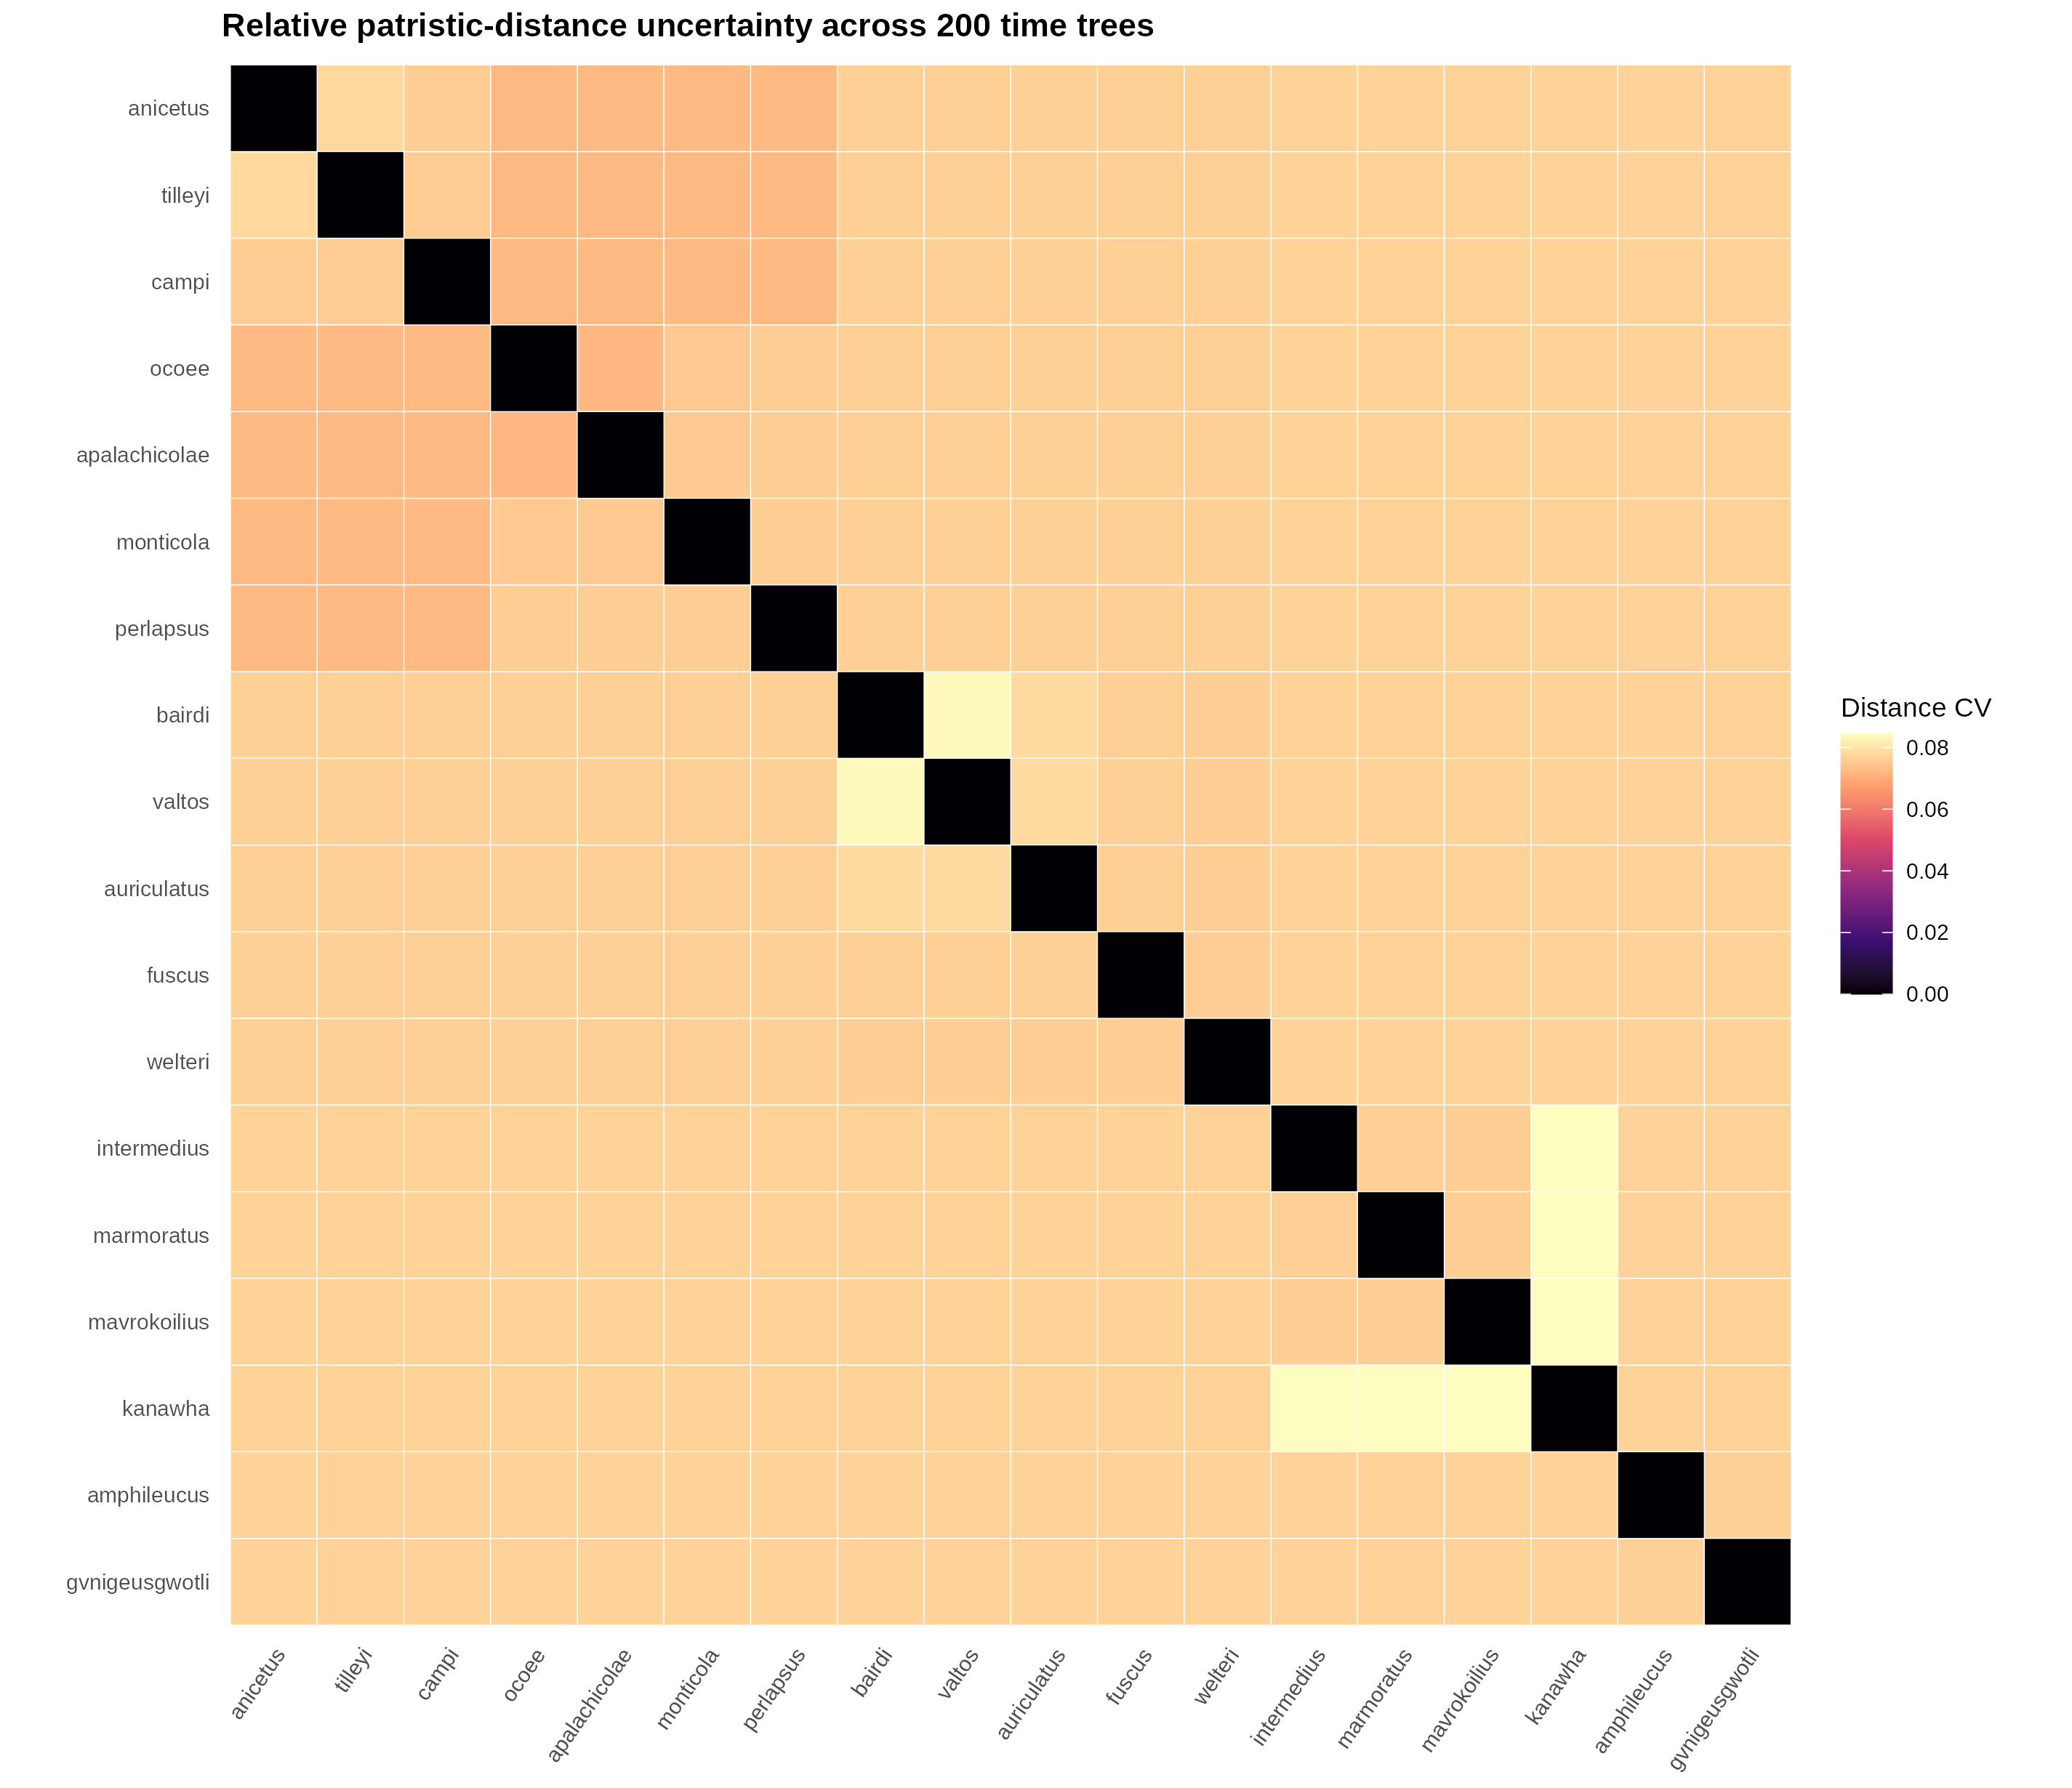

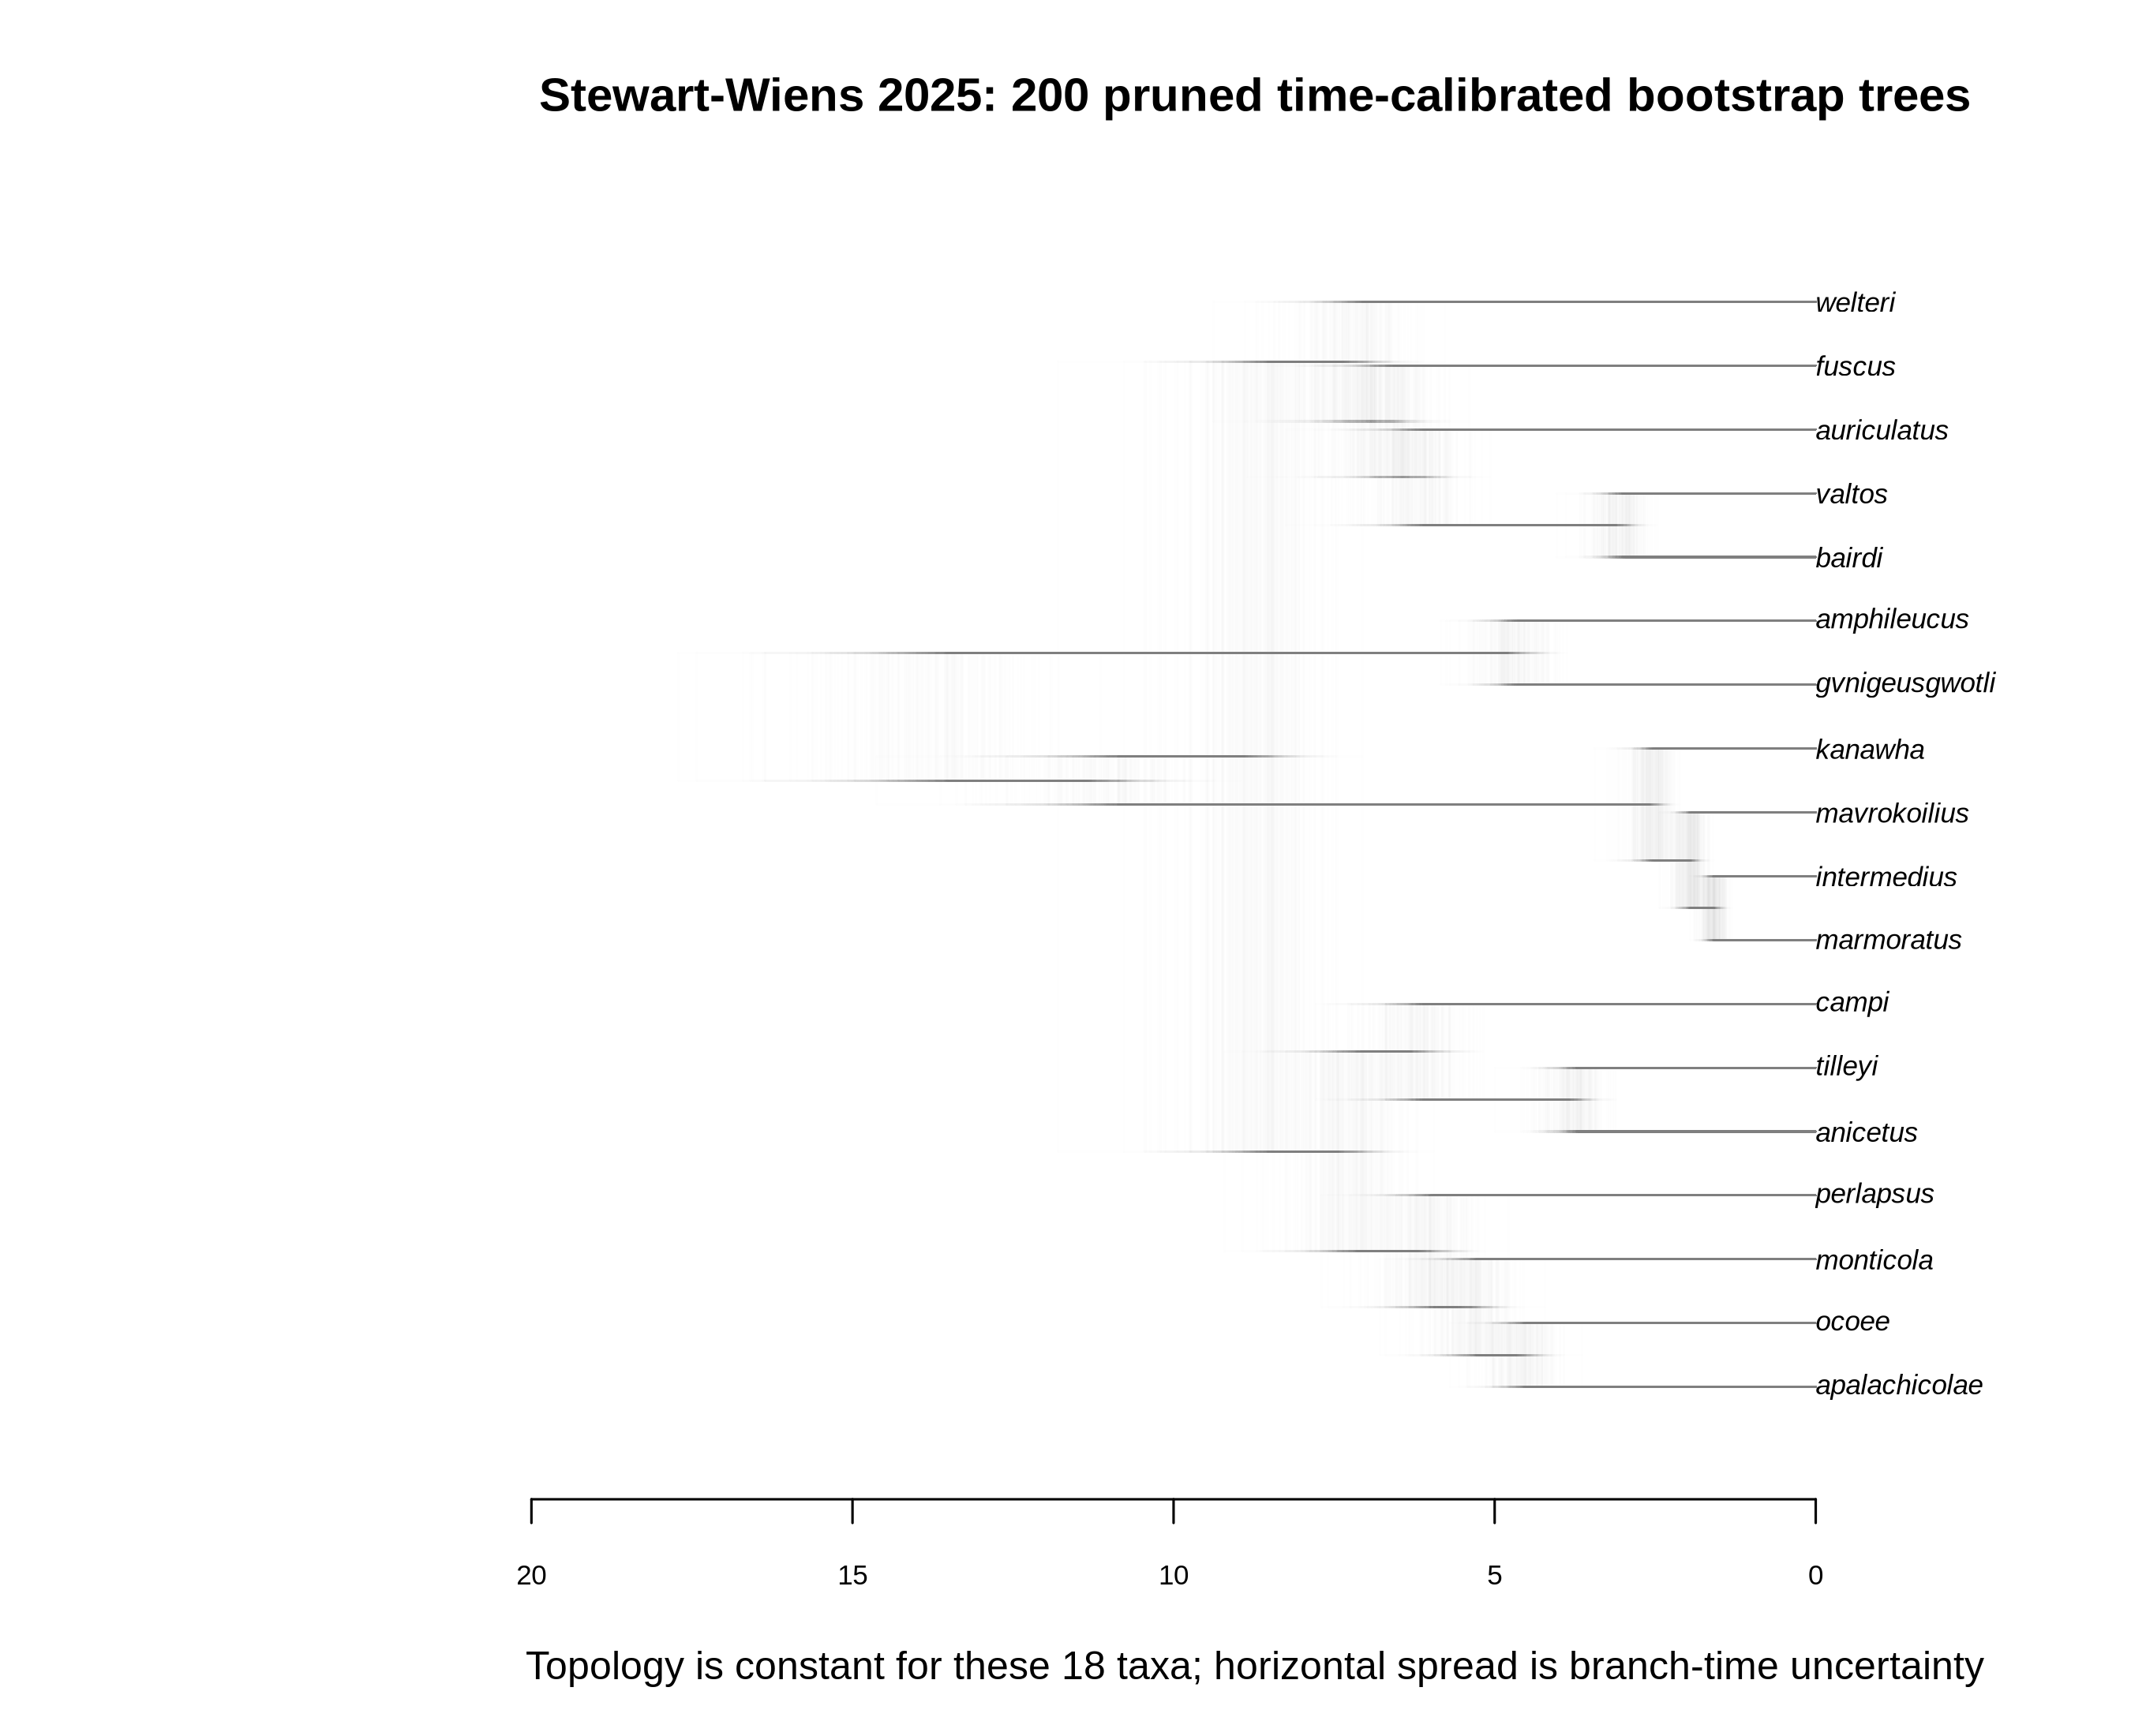

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tree_id,202,202,focal,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tree_role,202,3,stewart_wiens_2025_time_calibrated_bootstrap,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_tips,202.0,NaN,NaN,NaN,18.0,0.0,18.0,18.0,18.0,18.0,18.0
rooted,202,1,True,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fully_bifurcating,202,1,True,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
all_branch_lengths_positive,202,1,True,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
root_age_myr,202.0,NaN,NaN,NaN,13.985948,1.08535,11.133915,13.307581,13.879525,14.564293,17.716648
root_to_tip_range_before_padding_myr,202.0,NaN,NaN,NaN,0.000002,0.000001,0.0,0.000001,0.000002,0.000002,0.000003
maximum_terminal_padding_myr,202.0,NaN,NaN,NaN,0.000002,0.000001,0.0,0.000001,0.000002,0.000002,0.000003
strict_ultrametric_after_padding,202,1,True,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,topology,descendant_species,biological_interpretation
0,focal_only,kanawha;mavrokoilius,clade occurs only in collaborator focal tree
1,published_only,intermedius;marmoratus;mavrokoilius,clade occurs in published main and all 200 bootstrap trees


In [4]:
for figure in [
    "results/figures/corrected/phylogeny/phylogeny_focal_vs_published_topology_analysis18_v1.png",
    "results/figures/corrected/phylogeny/phylogeny_root_age_uncertainty_analysis18_v1.png",
    "results/figures/corrected/phylogeny/phylogeny_patristic_uncertainty_analysis18_v1.png",
    "results/figures/corrected/phylogeny/phylogeny_published_bootstrap_density_analysis18_v1.png",
]:
    show_figure(figure)
uncertainty = read_csv("results/data/corrected/phylogeny/phylogeny_tree_uncertainty_metrics_analysis18_v1.csv")
topology = read_csv("results/data/corrected/phylogeny/phylogeny_topology_difference_analysis18_v1.csv")
display(uncertainty.describe(include="all").T)
display(topology)

## Review boundary

- The 18-tip tree is a deterministic trim used by the integrated analysis, not a
  newly inferred phylogeny.
- The published main tree and 200-tree sample are independent sensitivity surfaces.
- The older processed tree is not treated as an independent phylogenetic hypothesis.
- Tree uncertainty must accompany path coefficients; a single-tree result is not
  the complete inferential result.